In [2]:
import matplotlib.pyplot as plt
import numpy as np
import arc
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=False)
import os
from IPython.display import Latex
import scipy
import pandas as pd
from pandas import DataFrame
h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e


In [6]:
from pairinteraction.visualization.colormaps import alphamagma
import os
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')

atom1 = 'Rb'
atom2 ='Cs'
l1_0, l2_0 = 1, 1
l1_1, l2_1 = 1, 3
j1_0, j2_0 = 3/2, 3/2


n1_0 = 59
n2_0 = 59

n1_1 = 61
n2_1 = 57

l1_1 = 1
l2_1 = 3

j1_1 = 3/2
j2_1 = 3/2

if atom1 == 'Rb':
    arc_atom1 = arc.Rubidium()
elif atom1 == 'Cs':
    arc_atom1 = arc.Caesium()
if atom2 == 'Rb':
    arc_atom2 = arc.Rubidium()
elif atom2 == 'Cs':
    arc_atom2 = arc.Caesium()

path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\spreadsheets\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]} to {orbs[l1_1]}{orbs[l2_1]} j1j2({j1_0},{j2_0}).xlsx'

index=0
if os.path.exists(path):
    data = pd.read_excel(path)
    state1 = data['state1 (nlj)'][index]
    state2 = data['state2 (nlj)'][index]
    resonant1 = data['resonant1 (nlj)'][index]
    resonant2 = data['resonant2 (nlj)'][index]
    n1_0 = int(state1[0])
    n2_0 = int(state2[0])
    n1_1 = int(resonant1[0])
    n2_1 = int(resonant2[0])
    l1_1 = resonant1[1]
    l2_1 = resonant2[1]
    j1_1 = resonant1[2]
    j2_1 = resonant2[2]    


n_dif = 3
jdif = 3
ldif = 3
b=0
energy_unit = 'MHz'

ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=j1_0, j=j1_0)
ket1basis = pi.BasisAtom(atom1, n=(ket1.n,ket1.n), l=(ket1.l,ket1.l), j=(ket1.j,ket1.j), m=(ket1.m,ket1.m))
# print(type(ket1basis.states))
ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=j2_0, j=j2_0)
ket2basis = pi.BasisAtom(atom2, n=(ket2.n,ket2.n), l=(ket2.l,ket2.l), j=(ket2.j,ket2.j))

ket1_energy = ket1.get_energy(unit=energy_unit)
# print('ket1 energy = ' + str(ket1_energy) + energy_unit)
basis1 = pi.BasisAtom(atom1, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif), m=(-ket1.j-jdif, ket1.j+jdif))

ket2_energy = ket2.get_energy(unit=energy_unit)
# print('ket2 energy = ' + str(ket2_energy) + energy_unit)

basis2 = pi.BasisAtom(atom2, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+ldif), j=(1/2,ket2.j+jdif), m=(-ket2.j-jdif,ket2.j+jdif))


In [4]:

ns = np.arange(40,91,1)
ns1 =np.arange(40,91,1)
l1, l2 = 2, 2
j1, j2 = 5/2, 3/2

theta, phi = 0, 0
dn = 5
deltamax = 1e9

X, Y = np.meshgrid(ns, ns)
Z = np.zeros(X.shape)
n1s=[]
n2s=[]
C6s=[]
for n1 in ns:
    for n2 in ns1:
        
        calc = arc.PairStateInteractions(arc_atom1, n1, l1, j1, n2, l2, j2, m1=j1, m2=j2, interactionsUpTo = 2, s=1/2, s2=1/2, atom2 = arc_atom2)
        C6 = calc.getC6perturbatively(theta, phi, dn, deltamax)
        if C6 is not None:
            # print(f'n1={n1}, n2={n2}, C6={C6}')
            Z[list(ns1).index(n2), list(ns).index(n1)] = C6
            
            n1s.append(n1)
            n2s.append(n2)
            C6s.append(C6)
    print('n1, ' + str(n1))

data = pd.DataFrame({'n1' : n1s, 'n2' : n2s, 'C6' : C6s})
if not os.path.exists(C6_path):
    os.makedirs(C6_path)
data.to_csv(C6_path + f'\\{orbs[l1_0]}{orbs[l2_0]} j1j2({j1},{j2}).csv')


n1, 40
n1, 41
n1, 42
n1, 43
n1, 44
n1, 45
n1, 46
n1, 47
n1, 48
n1, 49
n1, 50
n1, 51
n1, 52
n1, 53
n1, 54
n1, 55
n1, 56
n1, 57
n1, 58
n1, 59
n1, 60
n1, 61
n1, 62
n1, 63
n1, 64
n1, 65
n1, 66
n1, 67
n1, 68
n1, 69
n1, 70
n1, 71
n1, 72
n1, 73
n1, 74
n1, 75
n1, 76
n1, 77
n1, 78
n1, 79
n1, 80
n1, 81
n1, 82
n1, 83
n1, 84
n1, 85
n1, 86
n1, 87
n1, 88
n1, 89
n1, 90


OSError: [Errno 22] Invalid argument

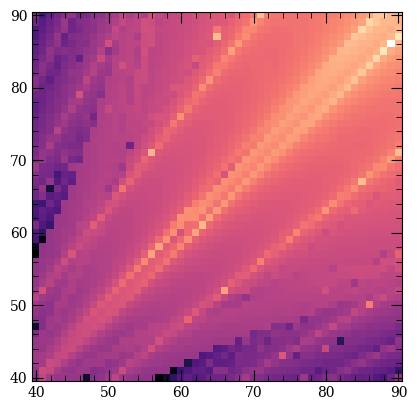

In [19]:
plot_n1s=[]
plot_n2s=[]
fig, ax = plt.subplots()
ax.set_aspect('equal', adjustable='box')
cmap = ax.imshow(np.log10(np.abs(Z)), cmap=alphamagma.reversed(), extent=(ns[0]-0.5, ns[-1]+0.5, ns1[0]-0.5, ns1[-1]+0.5), origin='lower')

col = 0
for l1_1 in [l1-1, l1+1]:
    for l2_1 in [l2-1, l1+1]:
        path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\spreadsheets\\{atom1}{atom2}\\{orbs[l1]}{orbs[l2]} to {orbs[l1_1]}{orbs[l2_1]} j1j2({j1},{j2}).xlsx'
        if os.path.exists(path):
            df = pd.read_excel(path)
            plot_n1s = df['n1_0'].to_numpy()
            plot_n2s = df['n2_0'].to_numpy()
            ax.plot(plot_n1s, plot_n2s, 'o', markerfacecolor='none', markersize=8, color=colours[col], markeredgewidth=2, label = f'{orbs[l1_1]} {orbs[l2_1]}')
            col+=1
        else:
            continue
print(df['n1_0'])
# np.concatenate(plot_n1s).flatten()
# np.concatenate(plot_n2s).flatten()
print(plot_n1s)

plt.legend()

ax.plot(data['n1'].to_numpy()[inds], data['C6'].to_numpy()[inds])

ax.set_ylabel(r'$C_6$ (GHz $\mu m^6$)')
ax.set_xlabel(r'$n$')
plt.title(rf'$C_6$ coefficients for {atom1}{atom2} ' + f'$n{orbs[l1_0]}_{{{j1_0}}}$ - $n{orbs[l2_0]}_{{{j2_0}}}$ pair states')
plt.show()

In [1]:
# print(Z)
Zpos=np.zeros_like(Z)
Zneg=np.zeros_like(Z)

for i, x in enumerate(Z):
    for j, y in enumerate(x):
        if y>=0:
            Zpos[i][j]=y
        else:
            Zneg[i][j]=y
fig, ax = plt.subplots()

ax.set_aspect('equal', adjustable='box')
pos = ax.imshow(np.log10(np.abs(Zpos)), cmap='Reds', extent=(ns[0], ns[-1], ns[0], ns[-1]), origin='lower')
neg = ax.imshow(np.log10(np.abs(Zneg)), cmap='Blues', extent=(ns[0], ns[-1], ns[0], ns[-1]), origin='lower')

plt.colorbar(pos, label=r'$log_{10}$(|$C_6$| (GHz $\mu m^6$))')
plt.colorbar(neg)
plt.xlabel(r'$n_1$')
plt.ylabel(r'$n_2$')
plt.title(rf'$C_6$ coefficients for {atom1}{atom2} ' + f'${orbs[l1]}_{{{j1}}}$ - ${orbs[l2]}_{{{j2}}}$ pair states')
plt.show()

NameError: name 'np' is not defined

In [ ]:
plot_n1s=[]
plot_n2s=[]
fig, ax = plt.subplots()
ax.set_aspect('equal', adjustable='box')
cmap = ax.imshow(np.log10(np.abs(Z)), cmap=alphamagma.reversed(), extent=(ns[0]-0.5, ns[-1]+0.5, ns1[0]-0.5, ns1[-1]+0.5), origin='lower')

col = 0
for l1_1 in [l1-1, l1+1]:
    for l2_1 in [l2-1, l1+1]:
        path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\spreadsheets\\{atom1}{atom2}\\{orbs[l1]}{orbs[l2]} to {orbs[l1_1]}{orbs[l2_1]} j1j2({j1},{j2}).xlsx'
        if os.path.exists(path):
            df = pd.read_excel(path)
            plot_n1s = df['n1_0'].to_numpy()
            plot_n2s = df['n2_0'].to_numpy()
            ax.plot(plot_n1s, plot_n2s, 'o', markerfacecolor='none', markersize=8, color=colours[col], markeredgewidth=2, label = f'{orbs[l1_1]} {orbs[l2_1]}')
            col+=1
        else:
            continue
print(df['n1_0'])
# np.concatenate(plot_n1s).flatten()
# np.concatenate(plot_n2s).flatten()
print(plot_n1s)

plt.legend()

cbar = plt.colorbar(cmap, label=r'$log_{10}$(|$C_6$| (GHz $\mu m^6$))')
# cbar.set_ticks(np.arange(-2,6))
plt.xlabel(r'$n_1$')
plt.ylabel(r'$n_2$')
plt.title(rf'$C_6$ coefficients for {atom1}{atom2} ' + f'${orbs[l1]}_{{{j1}}}$ - ${orbs[l2]}_{{{j2}}}$ pair states')
plt.show()